In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

### Functions

In [2]:
def sample_correlation_coefficient(I1, I2):
    cov = np.mean((I1 - np.mean(I1)) * (I2 - np.mean(I2)))
    return cov / np.sqrt(np.var(I1) * np.var(I2))

def sample_covariance(I1, I2):
    return np.mean((I1 - np.mean(I1)) * (I2 - np.mean(I2)))

def sample_correlation(I1, I2):
    return np.mean(I1 * I2)

def cross_correlation_function_manual(x, y, nlags):
    
    cross_corrs = []

    assert len(x) == len(y), "x and y must have the same length"
    assert nlags < len(x), "nlags must be less than the length of x and y"

    for i in range(nlags):

        x_reduced = x[:len(x) - i]
        y_shifted = y[i:]

        avg_x, var_x = np.mean(x_reduced), np.var(x_reduced)
        avg_y, var_y = np.mean(y_shifted), np.var(y_shifted)

        cov = np.mean((x_reduced - avg_x) * (y_shifted - avg_y))

        cross_corrs.append(cov / np.sqrt(var_x * var_y))

    return cross_corrs

def cross_correlogram(ts_spike_1, ts_spike_2):

    DeltaTs = []

    for t1 in ts_spike_1:
        for t2 in ts_spike_2:
            DeltaTs.append(t2 - t1)

    DeltaTs = np.array(DeltaTs)
    
    return DeltaTs

def generate_poisson_events(rate, T, dt=None, seed=42):

    rng = np.random.default_rng(seed)

    num_events = rng.poisson(rate*T)
    t_events = np.sort(rng.random(num_events)*T)

    if dt is not None:

        train = np.zeros(int(T/dt))
        idx_events = (t_events/dt).astype(int)
        train[idx_events] = 1

        # counting process
        counts = np.cumsum(train)
        
        return t_events, counts, train

    return t_events

def generate_correlated_poisson_spike_trains(rate, t_start, t_stop, dt, c, seed=43):

    rng = np.random.default_rng(seed)

    mother_rate = rate/c # generate more spikes than needed
    mother_train, mother_ts_spike = generate_poisson_spike_train(rate=mother_rate, t_start=t_start,
                                                t_stop=t_stop, dt=dt, seed=seed)

    N_mother_spikes = len(mother_ts_spike)
    N_trains_spikes= int(N_mother_spikes * c) # actual number of spike to have the desired rate

    ts_spike_1 = np.sort(rng.choice(mother_ts_spike, N_trains_spikes, replace=False))
    ts_spike_2 = np.sort(rng.choice(mother_ts_spike, N_trains_spikes, replace=False))

    return ts_spike_1, ts_spike_2

def cross_correlation_function_spikes(T, ts_pre, ts_post, binsize, nlags, lag_step=1, result='corr', both_side=False):
    """
    Option for result are 'cov', 'corrcoef', 'corr'.
    """
    # Doubt: should I shift before or after binning?
    # Actually it should be identical, as I am shifting of a multiple of the binsize

    shifts_nbins = [lag_step*i for i in range(nlags)]
    shifts_time = [binsize*nbins for nbins in shifts_nbins]
    cross_corrs = []

    for shift_nbins, shift_time in zip(shifts_nbins, shifts_time):

        ts_pre_shifted = ts_pre + shift_time
        
        counts_pre, _ = np.histogram(ts_pre_shifted, bins=np.arange(0, T, binsize))
        counts_post, _ = np.histogram(ts_post, bins=np.arange(0, T, binsize))

        if result == 'corr':
            cross_corrs.append(sample_correlation(counts_pre[shift_nbins:], 
                                                  counts_post[shift_nbins:]))
        elif result == 'corrcoef':
            cross_corrs.append(sample_correlation_coefficient(counts_pre[shift_nbins:], 
                                                              counts_post[shift_nbins:]))
        elif result == 'cov':
            cross_corrs.append(sample_covariance(counts_pre[shift_nbins:], 
                                                 counts_post[shift_nbins:]))
    
    if both_side:
        shifts_nbins_rev = [lag_step*i for i in range(1, nlags)] 
        shifts_time_rev = [binsize*nbins for nbins in range(1, nlags)]
        cross_corrs_rev = []

        for shift_nbins, shift_time in zip(shifts_nbins_rev, shifts_time_rev):
            
            ts_post_shifted = ts_post + shift_time

            counts_pre, _ = np.histogram(ts_pre, bins=np.arange(0, T, binsize))
            counts_post, _ = np.histogram(ts_post_shifted, bins=np.arange(0, T, binsize))

            if result == 'corr':
                cross_corrs_rev.append(sample_correlation(counts_post[shift_nbins:], 
                                                      counts_pre[shift_nbins:]))
            elif result == 'corrcoef':
                cross_corrs_rev.append(sample_correlation_coefficient(counts_post[shift_nbins:], 
                                                          counts_pre[shift_nbins:]))
            elif result == 'cov':
                cross_corrs_rev.append(sample_covariance(counts_post[shift_nbins:], 
                                                 counts_pre[shift_nbins:]))
                
        shifts_time = [-t for t in shifts_time_rev[::-1]] + shifts_time
        cross_corrs = cross_corrs_rev[::-1] + cross_corrs
        
    return shifts_time, cross_corrs

### Second moment for a Poisson counting process

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 1096.01it/s]


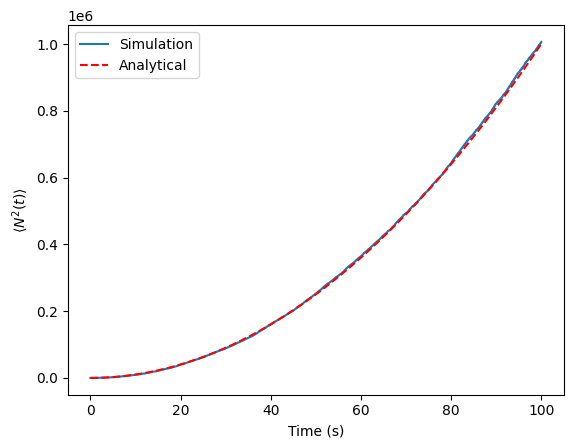

In [3]:
def analytical(rate, t): return rate**2 * t**2 + rate * t

rate = 10 # Hz

T = 100 # s, total recording time
dt = 0.001 # for the counting process
times = np.arange(0, T, dt)

num_trials = 10 # number of trials for the expectation!

N2s = np.zeros_like(times)

for trial in tqdm(range(num_trials)):

    t_events, counts, _ = generate_poisson_events(rate, T, dt=dt, seed=trial)
    N2s += counts**2

N2s /= num_trials

plt.plot(times, N2s, '-', label='Simulation')
plt.plot(times, analytical(rate, times), 'r--', label='Analytical')
plt.xlabel('Time (s)')
plt.ylabel(r'$\left \langle N^2(t) \right \rangle$')
plt.legend()
plt.show()

### Autocorrelation for a Poisson counting process

100%|██████████| 10/10 [00:00<00:00, 334.94it/s]


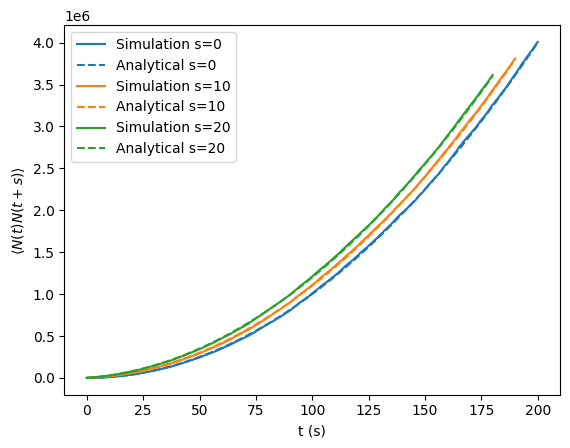

In [4]:
def analytical(rate, t, s): 
    if s>=0:
        return rate**2 *t*(t+s) + rate*t
    else:
        return rate**2 *t*(t+s) + rate*s


rate = 10 # Hz
T = 200 # s, total recording time
dt = 0.001 # for the counting process
times = np.arange(0, T, dt)

s = [0, 10, 20] # s

num_trials = 10 # number of trials for the expectation

NtNts = [[] for _ in s]

for trial in tqdm(range(num_trials)):

    t_events, counts, _ = generate_poisson_events(rate, T, dt=dt, seed=trial)

    for i, s_ in enumerate(s):
        idx = int(s_/dt)

        if idx == 0:
            NtNts[i].append(counts**2)
        else:
            NtNts[i].append(counts[:-idx] * counts[idx:])

NtNts = [np.mean(NtNt, axis=0) for NtNt in NtNts]

# plot
for i, s_ in enumerate(s):
    
    idx = int(s_/dt)
    if idx > 0:
        times_ = times[:-idx]
    else:
        times_ = times

    color = 'tab:blue' if i == 0 else 'tab:orange' if i == 1 else 'tab:green'

    plt.plot(times_, NtNts[i], label=f'Simulation s={s_}', color=color)
    plt.plot(times_, analytical(rate, times_, s_), label=f'Analytical s={s_}', color=color, linestyle='--')

plt.xlabel('t (s)')
plt.ylabel(r'$\left \langle N(t)N(t+s) \right \rangle$')
plt.legend()
plt.show()

### Autocorrelation for the derivative of a Poisson counting process

We compute the autocorrelation for:
$$
y(t) = \lim_{\Delta t \to 0} \frac{N(t+\Delta t) - N(t)}{\Delta t}
$$

We cannot really take the limit to zero. 
But we will use three different values of $\Delta t$, smaller and smaller, to approximate the derivative.

100%|██████████| 100/100 [00:00<00:00, 900.71it/s]


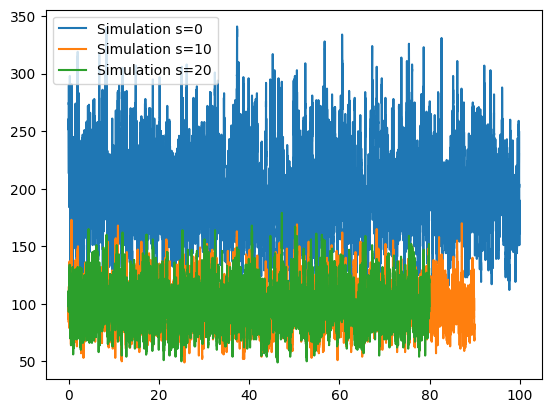

In [5]:
# Here we do not exploit the stationarity of the process, so we compute the autocorrelation
# for a pair of t and t+s, and then average over trials
# This way is less efficient of course than assuming stationarity, but this way we show that indeed the result
# does not depend on the time t.

def analytical(rate, t, s):

    if s>=0:
        return np.ones_like(t)*rate**2
    else:
        return np.ones_like(t)*(rate**2 + rate*10000)
    
DeltaT = 0.1

T = 100
dt = 0.001
times = np.arange(0, T, dt)
rate=10

s = [0, 10, 20]
num_trials = 100

autocorrs = [[] for _ in s]

for trial in tqdm(range(num_trials)):
        
    t_events, counts, _ = generate_poisson_events(rate, T, dt=dt, seed=trial)
    
    idx_deltat = int(DeltaT/dt)
    process = (counts[idx_deltat:] - counts[:-idx_deltat])/DeltaT
    
    for i, s_ in enumerate(s):

        idx = int(s_/dt)
        
        if idx == 0:
            autocorrs[i].append(process**2)
        else:
            autocorrs[i].append(process[:-idx]*process[idx:])

autocorrs = [np.mean(autocorr, axis=0) for autocorr in autocorrs]

# plot
for i, s_ in enumerate(s):
    
    times_ = times[:-int(DeltaT/dt)]

    idx = int(s_/dt)
    if idx > 0:
        times_ = times_[:-idx]
    else:
        times_ = times_

    color = 'tab:blue' if i == 0 else 'tab:orange' if i == 1 else 'tab:green'

    plt.plot(times_, autocorrs[i], label=f'Simulation s={s_}', color=color)
    #plt.plot(times_, analytical(rate, times_, s_), label=f'Analytical s={s_}', color=color, linestyle='--')
plt.legend()
plt.show()

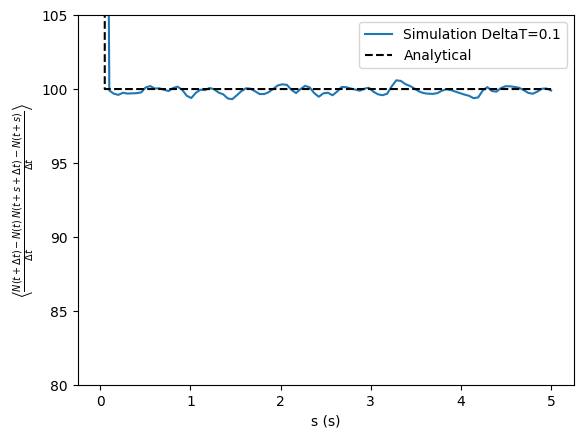

In [7]:
# Now we explot the stationarity; on the x-axis we put s instead of time (times is fixed)
# And instead of plotting three plots for 3 different s, we plot three plots for 3 differente DeltaT,
# to show the effect of the limit DeltaT -> 0
# Notice: for high rate, the value of dt must be very small (rate=10, dt=1e-4)

def analytical(rate, s): 

    x = np.ones_like(s) * (rate**2)
    x[np.where(s==0)] = 10000
    
    return x

T = 10000
dt = 0.0001
times = np.arange(0, T, dt)
rate= 10

s = np.linspace(0, 5, 100)
DeltaTs = [0.1,]

autocorrs = [[] for _ in DeltaTs]

occurrences = []

for i, DeltaT in enumerate(DeltaTs):

    t_events, counts, _ = generate_poisson_events(rate, T, dt=dt, seed=i+39)
    process = (counts[int(DeltaT/dt):] - counts[:-int(DeltaT/dt)])/DeltaT
    
    for j, s_ in enumerate(s):

        idx = int(s_/dt)
        
        if idx == 0: prod = process**2
        else: prod = process[:-idx]*process[idx:]
        
        autocorrs[i].append(np.sum(prod)/(len(prod)))

# plot
plt.figure()

for i, DeltaT in enumerate(DeltaTs):

    plt.plot(s, autocorrs[i], label=f'Simulation DeltaT={DeltaT}')
    
plt.plot(s, analytical(rate, s), label=f'Analytical', linestyle='--', color='black')

plt.xlabel('s (s)')
plt.ylabel(r'$\left \langle \frac{N(t+\Delta t) - N(t)}{\Delta t} \frac{N(t+s+\Delta t) - N(t+s)}{\Delta t} \right \rangle$')
plt.legend()
plt.ylim(rate**2 -20, rate**2 +5)
plt.show()

### Cross-correlation function - no binning

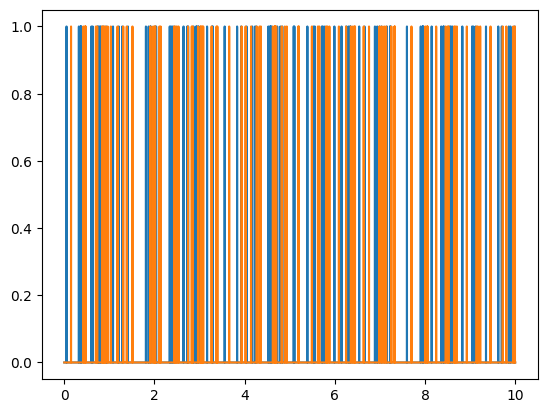

In [3]:
# Generate two identical Poisson spike train with a certain delay
T = 10
dt = 0.001
rate = 10
times = np.arange(0, T, dt)

pre_train = np.zeros(int(T/dt))
ts_pre_spike = np.random.rand(int(T*rate))*T
idx_pre_spike = (ts_pre_spike/dt).astype(int)
pre_train[idx_pre_spike] = 1

delay = 0.1
idx_delay = int(delay/dt)
post_train = np.zeros(int(T/dt))
post_train[idx_delay:] = pre_train[:-idx_delay]
ts_post_spike = ts_pre_spike + delay

plt.plot(times, pre_train)
plt.plot(times, post_train)


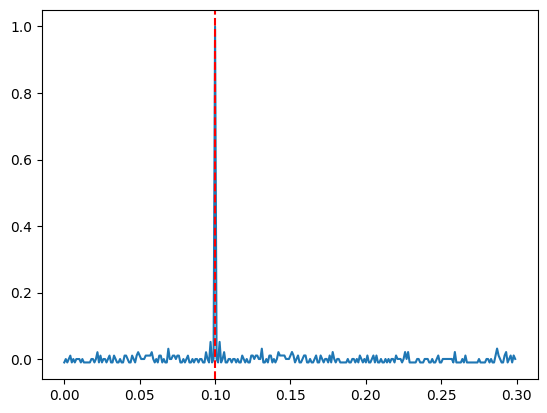

In [4]:
# What happens if I do the normal cross correlation on the binary vectors? (no binning)
nlags = 300
corrs_manual = cross_correlation_function_manual(pre_train, post_train, nlags)
delays = np.array(range(nlags)) * dt

plt.plot(delays, corrs_manual, label='manual')
plt.axvline(delay, color='r', linestyle='--', label='true delay')
plt.show()

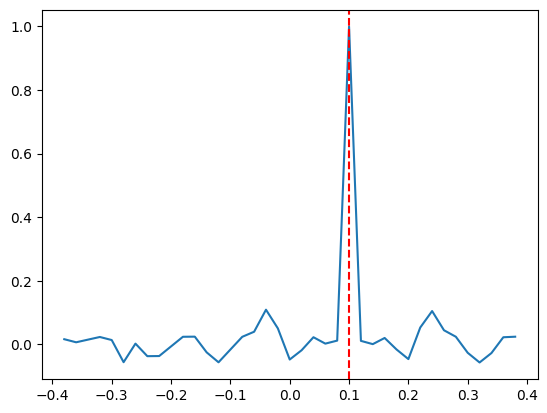

In [91]:
# What happens if I bin instead?
binsize = 0.02
nlags = 20
lag_step = 1

delays, corrs = cross_correlation_function_spikes(T, ts_pre_spike, ts_post_spike, binsize, nlags, lag_step, 
                                                  result='corrcoef', both_side=True)

plt.plot(delays, corrs, label='binned')
plt.axvline(delay, color='r', linestyle='--', label='true delay')
plt.show()

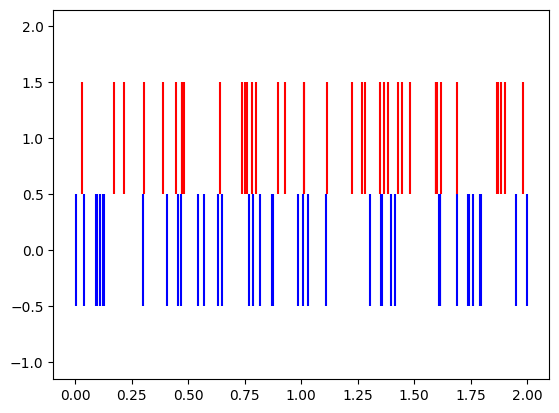

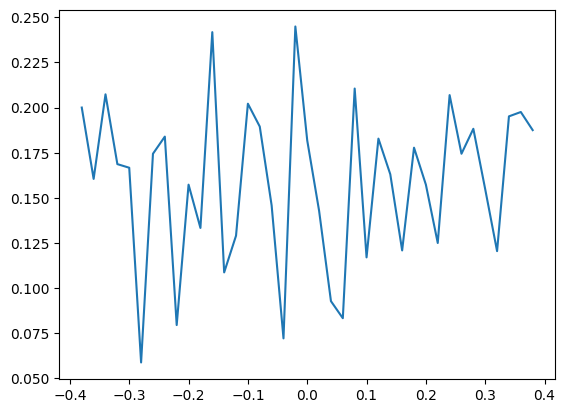

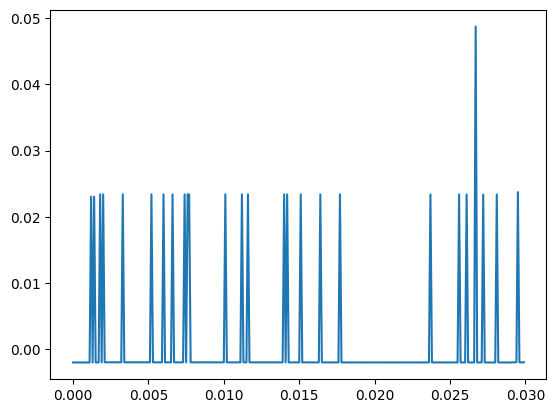

In [94]:
# What with 2 independent Poisson spike trains?
T = 2
dt = 0.0001
rate = 20

trains, ts_spike = generate_poisson_spike_train(rate, T, dt, N=2, seed=5)
ts_spike_1, ts_spike_2 = ts_spike

plt.eventplot(ts_spike, colors=['b', 'r'])
plt.show()

binsize = 0.02
nlags = 20
lag_step = 1

delays, corrs = cross_correlation_function_spikes(T, ts_spike_1, ts_spike_2, binsize, nlags, lag_step, both_side=True)

plt.plot(delays, corrs, label='binned')
plt.show()

nlags = 300
corrs_manual = cross_correlation_function_manual(trains[0], trains[1], nlags)
delays = np.array(range(nlags)) * dt

plt.plot(delays, corrs_manual, label='manual')
plt.show()

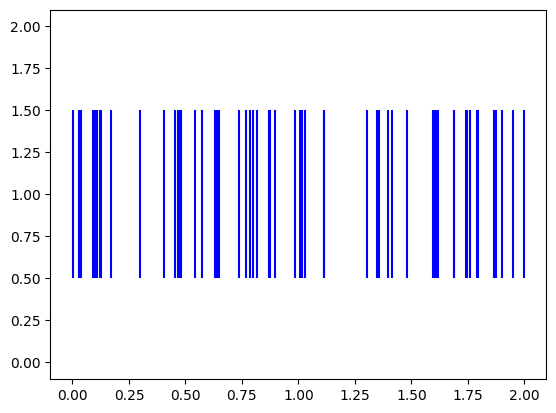

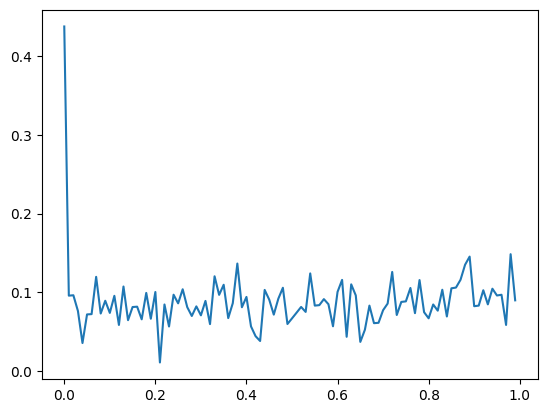

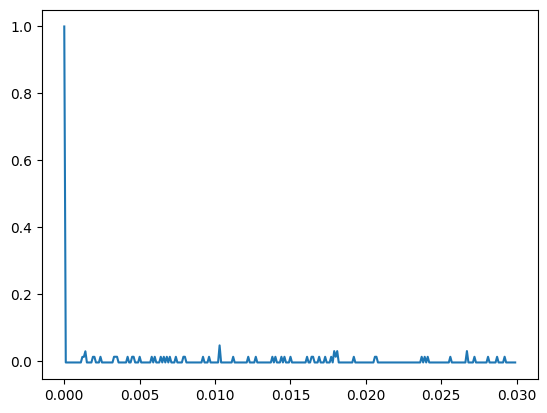

In [66]:
# Autocorrelation of a Poisson spike train
T = 2
dt = 0.0001
rate = 30

train, ts_spike = generate_poisson_spike_train(rate, T, dt, N=1, seed=5)
ts_spike = ts_spike[0]

plt.eventplot(ts_spike, colors=['b'])
plt.show()

binsize = 0.01
nlags = 100
lag_step = 1

delays, corrs = cross_correlation_function_spikes(T, ts_spike, ts_spike, binsize, nlags, lag_step)

plt.plot(delays, corrs, label='binned')
plt.show()

nlags = 300
corrs_manual = cross_correlation_function_manual(train[0], train[0], nlags)
delays = np.array(range(nlags)) * dt

plt.plot(delays, corrs_manual, label='manual')
plt.show()

### Cross-correlogram

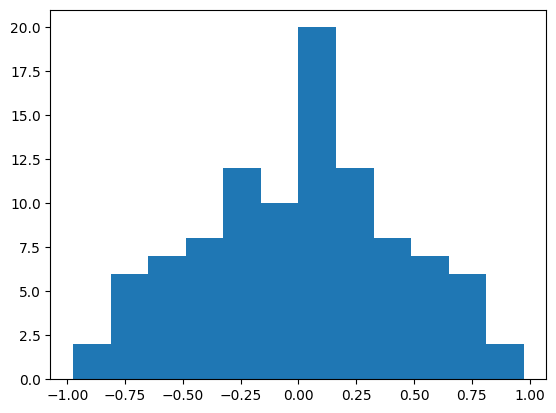

In [37]:
DeltaTs = cross_correlogram(ts_pre_spike, ts_pre_spike)
plt.hist(DeltaTs, bins=12)
plt.show()

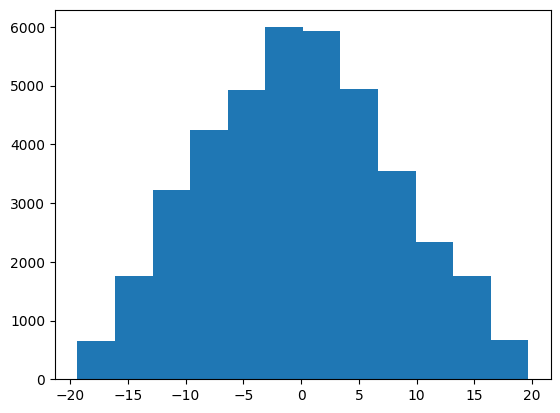

In [45]:
train1, ts_spike_1 = generate_poisson_spike_train(rate=10, t_start=0 , t_stop=20, dt=0.0001, seed= 2)
train2, ts_spike_2 = generate_poisson_spike_train(rate=10, t_start=0 , t_stop=20, dt=0.0001, seed= 10)

DeltaTs = cross_correlogram(ts_spike_1, ts_spike_2)
plt.hist(DeltaTs, bins=12)
plt.show()

### Gjorgjieva et al., 2011 - Triplet STDP 

#### Neuron Model

In [2]:
def membrane_potential(t, ts_pre_spikes, weights, tau):

    effective_spikes = np.where(t>ts_pre_spikes, ts_pre_spikes, np.nan)
    delta_t = t - effective_spikes
    contributions = weights.reshape(-1, 1) * np.exp(-delta_t/tau)/tau
    return np.nansum(contributions)

def g(u, g0=0., dg0=1., u0=0.):

    return g0 + dg0*(u-u0)

def run_model(T, dt, seed, num_inputs, tau, rate, weights, g0, dg0, u0):

    rng = np.random.default_rng(seed)
    times = np.arange(0, T, dt)

    train_pre, ts_spike_pre = generate_poisson_spike_train(rate, T, dt, num_inputs, seed=rng.integers(1000))

    u = np.zeros_like(times)
    train_post = np.zeros_like(times)
    ts_spikes_post = []
    
    for i, t in enumerate(times):
    
        u[i] = membrane_potential(t, ts_spike_pre, weights, tau)
        g_val = g(u[i], g0, dg0, u0)

        if rng.random() < g_val*dt:
            train_post[i] = 1
            ts_spikes_post.append(t)

    return train_pre, train_post, ts_spike_pre, np.array(ts_spikes_post), u

def eps(s, tau):
    if s<0:
        return 0
    else:
        return np.exp(-s/tau)/tau
    
def analytical_cross_correlation(C_eps, rates, weights, g0, g1, u0):

    constant = (g0 - g1*u0) * rate
    correlation = g1*np.sum(rates*weights*C_eps)
    
    return constant + correlation


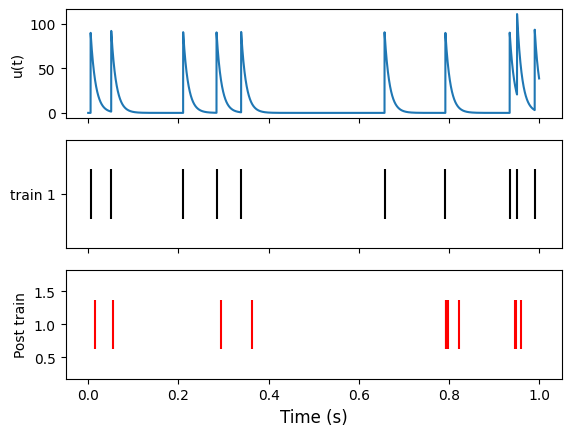

In [5]:
seed = 2
rng = np.random.default_rng(seed)

T = 1 # s
dt = 0.0001 
times = np.arange(0, T, dt)

num_inputs = 1
weights = np.ones(num_inputs)
rate = 10
tau = 0.011

train_pre, train_post, ts_spike_pre, ts_spike_post, u = run_model(T, dt, seed, num_inputs, tau, rate, weights, 0, 1, 0)

# Plot
fig, ax = plt.subplots(3, 1, sharex=True)
ax[0].set_ylabel('u(t)')
ax[0].plot(times, u)

ax[1].eventplot(ts_spike_pre, linelengths=0.75, color='black')
plt.xlabel('Time (s)', fontsize=12)
ax[1].set_yticks(range(num_inputs==1, num_inputs + int(num_inputs==1)), 
                 labels=["train " + str(i+1) for i in range(num_inputs)], fontsize=10)

ax[2].eventplot(ts_spike_post, linelengths=0.75, color='red')
plt.xlabel('Time (s)', fontsize=12)
ax[2].set_ylabel('Post train')
 
plt.show()

#### Correlation Coefficient

In [6]:
seed = 3
num_trials = 1

T = 10
dt = 0.0001
num_inputs = 1
tau = 0.01
rate = 20
weights = np.ones(num_inputs)
g0, dg0, u0 = 0, 1, 0

train_pre, train_post, ts_spike_pre, ts_spike_post, u = run_model(T, dt, seed,
                                                                num_inputs, tau, 
                                                                rate, 
                                                                weights, 
                                                                g0, dg0, u0)


pre_idx = 0

binsize = 0.02

counts_pre, _ = np.histogram(ts_spike_pre[pre_idx], bins=np.arange(0, T, binsize), )
counts_post, _ = np.histogram(ts_spike_post, bins=np.arange(0, T, binsize))

print(sample_correlation_coefficient(counts_pre, counts_post))

0.41119943767254863


#### Correlation Function

In [13]:
def cross_correlation_poisson_process(T, dt, ts_pre, ts_post, nlags=100, lag_step=1, both_side=False):

    times = np.arange(0, T, dt)
    cumulative_pre = np.zeros(len(times))
    cumulative_post = np.zeros(len(times))

    for i, t in enumerate(times):
        cumulative_pre[i] = np.sum(ts_pre < t)
        cumulative_post[i] = np.sum(ts_post < t)

    cross_corrs = []

    for i in range(1, nlags):
            
        cross_corrs.append(sample_correlation(cumulative_pre[i*lag_step:], cumulative_post[:-i*lag_step]))

    if both_side:
        cross_corrs_rev = []

        for i in range(1, nlags):
            cross_corrs_rev.append(sample_correlation(cumulative_post[i*lag_step:], cumulative_pre[:-i*lag_step]))

        cross_corrs = cross_corrs_rev[::-1] + cross_corrs

    lags = np.arange(1, nlags*lag_step, lag_step)*dt
    lags_rev = np.arange(1, nlags*lag_step, lag_step)*dt
    lags = np.concatenate((-lags_rev[::-1], lags))
    return lags, cross_corrs

In [14]:
seed = 4
num_trials = 10

T = 10
dt = 0.0001
num_inputs = 10
tau = 0.011
rate = 10
weights = np.ones(num_inputs)
g0, dg0, u0 = 0, 10, 0

In [15]:
train_pre, train_post, ts_spike_pre, ts_spike_post, u = run_model(T, dt, seed,
                                                                num_inputs, tau, 
                                                                rate, 
                                                                weights, 
                                                                g0, dg0, u0)

pre_idx = 0
binsize = 0.01

In [16]:
cross_correlation_poisson_process(T, dt, ts_spike_pre[pre_idx], ts_spike_post, nlags=100, lag_step=1, both_side=True)

(array([-0.0099, -0.0098, -0.0097, -0.0096, -0.0095, -0.0094, -0.0093,
        -0.0092, -0.0091, -0.009 , -0.0089, -0.0088, -0.0087, -0.0086,
        -0.0085, -0.0084, -0.0083, -0.0082, -0.0081, -0.008 , -0.0079,
        -0.0078, -0.0077, -0.0076, -0.0075, -0.0074, -0.0073, -0.0072,
        -0.0071, -0.007 , -0.0069, -0.0068, -0.0067, -0.0066, -0.0065,
        -0.0064, -0.0063, -0.0062, -0.0061, -0.006 , -0.0059, -0.0058,
        -0.0057, -0.0056, -0.0055, -0.0054, -0.0053, -0.0052, -0.0051,
        -0.005 , -0.0049, -0.0048, -0.0047, -0.0046, -0.0045, -0.0044,
        -0.0043, -0.0042, -0.0041, -0.004 , -0.0039, -0.0038, -0.0037,
        -0.0036, -0.0035, -0.0034, -0.0033, -0.0032, -0.0031, -0.003 ,
        -0.0029, -0.0028, -0.0027, -0.0026, -0.0025, -0.0024, -0.0023,
        -0.0022, -0.0021, -0.002 , -0.0019, -0.0018, -0.0017, -0.0016,
        -0.0015, -0.0014, -0.0013, -0.0012, -0.0011, -0.001 , -0.0009,
        -0.0008, -0.0007, -0.0006, -0.0005, -0.0004, -0.0003, -0.0002,
      

In [19]:
import multiprocessing

seed = 4
num_trials = 10

T = 10
dt = 0.0001
num_inputs = 10
tau = 0.011
rate = 10
weights = np.ones(num_inputs)
g0, dg0, u0 = 0, 10, 0

def run_trial(seed):
    
    train_pre, train_post, ts_spike_pre, ts_spike_post, u = run_model(T, dt, seed,
                                                                num_inputs, tau, 
                                                                rate, 
                                                                weights, 
                                                                g0, dg0, u0)

    pre_idx = 0
    binsize = 0.01
    # correlogram = cross_correlogram(ts_spike_pre[pre_idx], ts_spike_post)
    #print(len(ts_spike_post)/T)
    # return cross_correlation_function_spikes(T, ts_spike_pre[pre_idx], ts_spike_post, binsize, nlags=10, lag_step=1, 
    #                                          result='corr', both_side=True)

    return cross_correlation_poisson_process(T, dt, ts_spike_pre[pre_idx], ts_spike_post, nlags=10, lag_step=10, both_side=True)

with multiprocessing.Pool(12) as pool:
    results = list(tqdm(pool.imap(run_trial, seed + np.array(range(num_trials))), total=num_trials))

# results has a len of num_trials, each element is a tuple with the correlogram and the correlation function

100%|██████████| 10/10 [00:05<00:00,  1.81it/s]


ValueError: 'x' and 'y' must have the same size

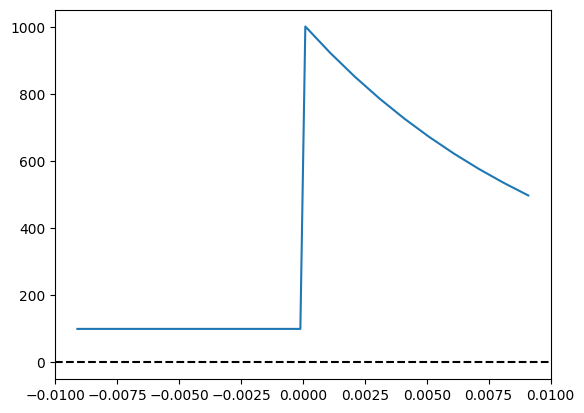

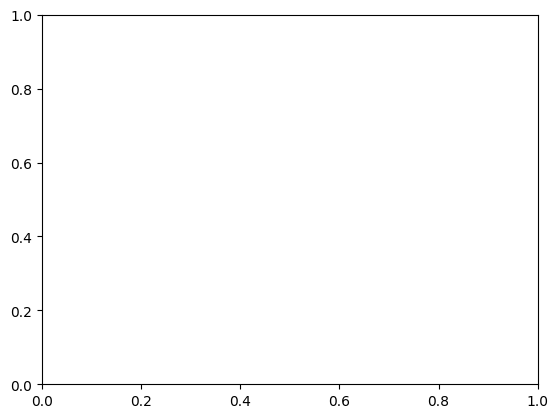

In [21]:
def analytic(s, tau, rate):
    if s<0:
        return rate**2
    else:
        return rate**2 + rate*np.exp(-s/tau)/tau
    

time_shifts = results[0][0]

corrs = np.array([results[i][1] for i in range(num_trials)]) # shape (num_trials, 2, nlags), second axis has time shifts and correlations
avg_corrs = np.mean(corrs, axis=0)
err_corrs = np.std(corrs, axis=0)/np.sqrt(num_trials)

plt.plot(time_shifts, [analytic(s, tau, rate) for s in time_shifts], label='analytic')
plt.axhline(0, color='black', linestyle='--')

plt.figure()
plt.errorbar(time_shifts, avg_corrs, yerr=err_corrs, fmt='o--')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Shift (s)')
plt.ylabel('Correlation')

# plt.figure()
# plt.hist(DeltaTs, bins=12)
# plt.show()

#### Correlation Coefficient and Number of Inputs

10it [00:10,  1.02s/it]


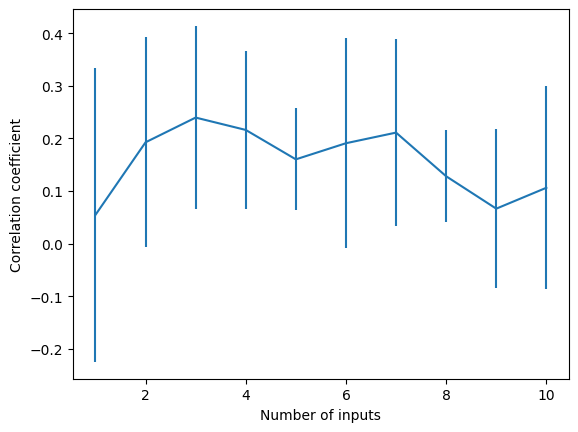

In [132]:
# How does the average correlation coefficient change with the number of inputs?
seed = 20

pre_idx = 0
num_inputs_ls = range(1, 11)
trials = 10
tau = 0.011
rate = 10

corrs = np.zeros((len(num_inputs_ls), trials))

for i, num_inputs in tqdm(enumerate(num_inputs_ls)):

    weights = np.ones(num_inputs)

    for j in range(trials):

        train_pre, ts_spike_pre = generate_poisson_spike_train(rate, T, dt, num_inputs, seed=seed+j+i)
        u = np.zeros(len(times))
        train_post = np.zeros(len(times))
        ts_spike_post = []

        for k, t in enumerate(times):
            u[k] = membrane_potential(t, ts_spike_pre, weights, tau)

            inst_rate = g(u[k], dg0 = 0.5)
            if rng.random() < inst_rate*dt:
                ts_spike_post.append(t)
                train_post[k] = 1

        counts_pre, _ = np.histogram(ts_spike_pre[pre_idx], bins=np.arange(0, T, binsize), )
        counts_post, _ = np.histogram(ts_spike_post, bins=np.arange(0, T, binsize))

        corrs[i, j] = sample_correlation_coefficient(counts_pre, counts_post)

mean_corrs = np.mean(corrs, axis=1)
std_corrs = np.std(corrs, axis=1)

plt.errorbar(num_inputs_ls, mean_corrs, yerr=std_corrs)
plt.xlabel('Number of inputs')
plt.ylabel('Correlation coefficient')
plt.show()

### Elephant

I tried this tool for the analysis of electrophysiological data. 
It gives you some routines to generate spike trains, and to analyze them.
It is too high level for me, since I still need to understand precisely what is going on.

In [5]:
from quantities import ms, s, Hz
from elephant.spike_train_generation import homogeneous_poisson_process, homogeneous_gamma_process

time = 5 * ms
print(time)

try:
    time + 5
except Exception as e:
    print(e)
    print("Hell right!")

5.0 ms
Unable to convert between units of "dimensionless" and "ms"
Hell right!


In [6]:
%%timeit
time + time

25.8 µs ± 1.85 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [7]:
%%timeit
5. + 5.

3.81 ns ± 0.103 ns per loop (mean ± std. dev. of 7 runs, 100,000,000 loops each)


In [8]:
np.random.seed(28)  # to make the results reproducible
spiketrain1 = homogeneous_poisson_process(rate=10*Hz, t_start=0.*ms, t_stop=10000.*ms)
spiketrain2 = homogeneous_gamma_process(a=3, b=10*Hz, t_start=0.*ms, t_stop=10000.*ms)

Text(0.5, 1.0, 'Figure 1')

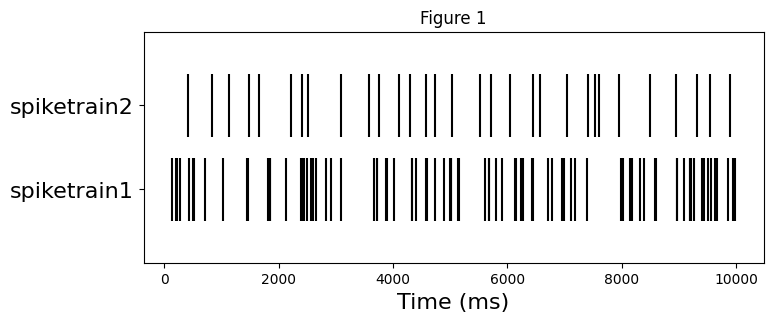

In [9]:
plt.figure(figsize=(8, 3))
plt.eventplot([spiketrain1.magnitude, spiketrain2.magnitude], linelengths=0.75, color='black')
plt.xlabel('Time (ms)', fontsize=16)
plt.yticks([0,1], labels=["spiketrain1", "spiketrain2"], fontsize=16)
plt.title("Figure 1")

In [10]:
from elephant.statistics import mean_firing_rate

print("The mean firing rate of spiketrain1 is", mean_firing_rate(spiketrain1))
print("The mean firing rate of spiketrain2 is", mean_firing_rate(spiketrain2))

The mean firing rate of spiketrain1 is 0.0086 1/ms
The mean firing rate of spiketrain2 is 0.0031 1/ms


#### Correlation coefficient

In [18]:
from elephant.spike_train_correlation import corrcoef
from elephant.conversion import BinnedSpikeTrain
import seaborn

In [24]:
st1 = homogeneous_poisson_process(
        rate=10.0*Hz, t_start=0.0*s, t_stop=10.0*s)
st2 = homogeneous_poisson_process(
        rate=10.0*Hz, t_start=0.0*s, t_stop=10.0*s)

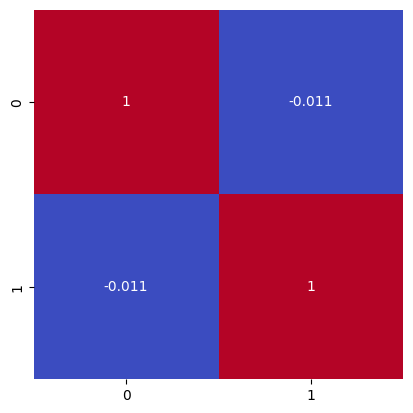

In [27]:
cc_matrix = corrcoef(BinnedSpikeTrain([st1, st2], bin_size=5*ms))

seaborn.heatmap(cc_matrix, annot=True, cmap='coolwarm', cbar=False)
plt.gca().set_aspect('equal')

### Neuromatch

Below I reproduce and explore the content of the Tutorial 2: Effects of Input Correlation of Neuromatch Academy.

#### Generate correlated input currents

In [ ]:
seed = 12
rng = np.random.default_rng(seed)

T = 2 # s
dt = 0.0001 # s

tau_m = 0.02

mu1 = 20.
mu2 = 20.
sigma_1 = 7.5
sigma_12 = 7.5
sigma_2 = 7.5
c = 0.3 # correlation coefficient

noise_1 = rng.standard_normal(int(T/dt)) * sigma_1 * np.sqrt(tau_m)
noise_2 = rng.standard_normal(int(T/dt)) * sigma_2 * np.sqrt(tau_m)
noise_12 = rng.standard_normal(int(T/dt)) * sigma_12 * np.sqrt(tau_m)

I1 = mu1 + np.sqrt(1. - c) * noise_1 + np.sqrt(c) * noise_12
I2 = mu2 + np.sqrt(1. - c) * noise_2 + np.sqrt(c) * noise_12

print(sample_correlation_coefficient(I1, I2))
print(sample_correlation_coefficient(I1, I2))

0.30015859114246585
0.30015859114246596


#### Generate Correlated Poisson Spikes Trains

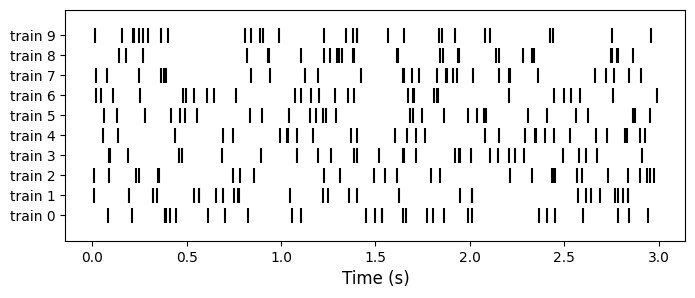

In [ ]:
# Uncorrelated
seed = 11

T = 3 # s
dt = 0.0001 # s

trains = []
for i in range(10):
    train_pre, ts_spike_pre = generate_poisson_spike_train(rate=10, t_start=0 , 
                                                   t_stop=T, dt=dt, seed= seed +i)
    
    trains.append(ts_spike_pre)

plt.figure(figsize=(8, 3))
plt.eventplot(trains, linelengths=0.75, color='black')
plt.xlabel('Time (s)', fontsize=12)
plt.yticks(range(10), labels=["train " + str(i) for i in range(10)], fontsize=10)
plt.show() 

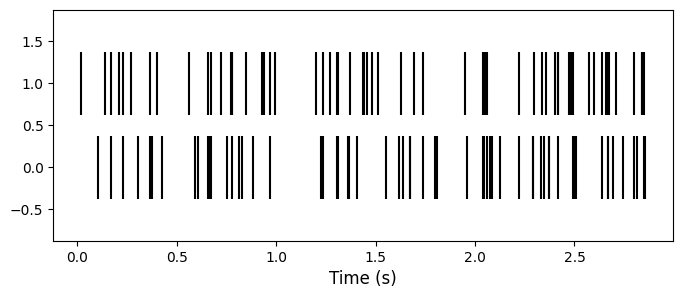

In [107]:
# Correlated
# The idea is pretty simple: if you want two spike trains with correlation 0.2 and a rate of 20 Hz
# You make a spike train with a rate of 20/0.2 = 100 Hz and then you randomly select the spikes
# to make spike trains with a rate of 20 Hz. 
# There is a 0.2 chance of having the same spike, so you will have a correlation of 0.2.

seed = 12
rng = np.random.default_rng(seed)

T = 3 # s
dt = 0.0001 # s

c = 0.2 # correlation coefficient
rate = 20 

mother_rate = rate/c # generate more spikes than needed
mother_train, mother_ts_spike = generate_poisson_spike_train(rate=mother_rate, t_start=0,
                                            t_stop=T, dt=dt, seed=seed)

N_mother_spikes = len(mother_ts_spike)
N_trains_spikes= int(N_mother_spikes * c) # actual number of spike to have the desired rate

ts_spike_1 = np.sort(rng.choice(mother_ts_spike, N_trains_spikes, replace=False))
ts_spike_2 = np.sort(rng.choice(mother_ts_spike, N_trains_spikes, replace=False))

plt.figure(figsize=(8, 3))
plt.eventplot([ts_spike_1, ts_spike_2], linelengths=0.75, color='black')
plt.xlabel('Time (s)', fontsize=12)
plt.show() 

#### Correlation coefficient between spike trains

In [142]:
seed = 100

trials = 100
rate = 20 # Hz
c = 0.2
T = 100 # s
dt = 0.0001 # s
bin_size = 0.02 # s

r12 = np.zeros(trials)

for i in range(trials):

    ts_spike_1, ts_spike_2 = generate_correlated_poisson_spike_trains(rate, t_start=0 , 
                                                   t_stop=T, dt=dt, c=c, seed= seed +i)

    counts1, _ = np.histogram(ts_spike_1, bins=np.arange(0, T, bin_size))
    counts2, _ = np.histogram(ts_spike_2, bins=np.arange(0, T, bin_size))

    r12[i] = sample_correlation_coefficient(counts1, counts2)

r12 = np.mean(r12)


print(f'True corr coe = {c:.3f}')
print(f'Simu corr coe = {r12.mean():.3f}')

True corr coe = 0.200
Simu corr coe = 0.198
